In [1]:
%load_ext autoreload
%autoreload 2

In [169]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from collections import Counter

# from simulator import Simulation
from tqdm.auto import tqdm
import itertools
import matplotlib as mpl
from collections import OrderedDict, defaultdict

from voting_mechanism_design.agents.pairwise_badgeholder import PairwiseBadgeholder, PairwiseBadgeholderPopulation
from voting_mechanism_design.projects.project import Project, ProjectPopulation
from voting_mechanism_design.funds_distribution.pairwise_binary import PairwiseBinary
from voting_mechanism_design.sim import RoundSimulation

from voting_mechanism_design.agents.quorum_badgeholder import QuorumBadgeholder, QuorumBadgeholderPopulation
from voting_mechanism_design.funds_distribution.threshold_and_aggregate import ThresholdAndAggregate

from voting_mechanism_design.mapping import mapping

# # OP simulator configuration
# from voting_mechanism_design.legacy.op_simulator import Simulation as OPSimulation
# from voting_mechanism_design.legacy.op_simulator import Round as OPRound
# from voting_mechanism_design.legacy.op_simulator import Voter as OPVoter
# from voting_mechanism_design.legacy.op_simulator import Project as OPProject

import itertools
import numpy as np
import choix
import math

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from tqdm.auto import tqdm
from joblib import Parallel, delayed

warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [181]:
def run_single_quorum_threshold_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        # configuration specific to quorum+threshold voting method
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed=1234, 
        normalize = False, 
        vote_model = 'linear',
        funding_model = 'linear'
    ):
    # create voters
    voters = []
    for ii in range(n_badgeholders):
        assert badgeholder_laziness_vec[ii] >= 0
        v = QuorumBadgeholder(
            badgeholder_id=ii,
            total_funds=max_funding,
            min_vote=min_vote_amt,  
            max_vote=max_vote_amt,
            laziness=badgeholder_laziness_vec[ii],
            expertise=badgeholder_expertise_vec[ii],
            coi_factor=0, 
            vote_model = vote_model
            #,expertise_model="k2"
        )
        voters.append(v)
    badgeholder_pop=QuorumBadgeholderPopulation()
    badgeholder_pop.add_badgeholders(voters)

    # add projects
    projects = []
    for ii in range(n_projects):
        p = Project(
            project_id=ii,
            true_impact=project_impact_vec[ii],  
            owner_id=None,  
        )
        projects.append(p)
    project_population = ProjectPopulation()
    project_population.add_projects(projects)

    # ##  Voting Simulation
    fund_distribution_model = ThresholdAndAggregate(
        scoring_method=scoring_fn,
        quorum=quorum,
        min_amount=0,
        normalize = normalize,
        funding_model = funding_model
    )
    simulation_obj = RoundSimulation(
        badgeholder_population=badgeholder_pop,
        projects=project_population,
        funding_design=fund_distribution_model,
        random_seed=random_seed
    )
    projects = project_population.get_projects()
    simulation_obj.run()
    #for v in voters:
        #print(int((1 - v.laziness_factor) * v.project_population.num_projects))


    projectid2score = simulation_obj.projectid2score
    projectid2funding = simulation_obj.projectid2funding
    


    #INCENTIVE ALIGNMENT MEASUREMENT
    #dictionary: key -- voter, value -- list of dictionaries, CHANGED TO A DICTIONARY -- {voter:{project_id: amount, project_id: amount ...},...}
    diff = {}
    for v in voters:
        v_funding = v.get_vote_dict()
        print("Voter funding:")
        print(v.get_vote_dict())
        print("\n")
        v_diff={} #dictionary: key -- project_id, value -- difference
        for project_id in range(n_projects):
            #print(f"Voter: {v.badgeholder_id} voted {v_funding[project_id]} for project {project_id}. ")
            #print(f"Simulation voted {projectid2funding[project_id]} for project {project_id}, difference is {abs( v_funding[project_id] - projectid2funding[project_id])}\n")
            #print("----------------------")
            v_diff[project_id] = abs( v_funding[project_id] - projectid2funding[project_id])
        print("Funding Diff:")
        print(v_diff)
        print("\n")
        diff[v] = v_diff
    
    # for easy comparison
    projectid2score = OrderedDict(projectid2score)
    #print("Projectid2funding:")
    #print(projectid2funding)
    #print("\n")
    projectid2funding = OrderedDict(projectid2funding)
    #ranks = np.argsort(np.asarray(list(projectid2score.values())))
    #projectid2rank = {ii:ranks[ii] for ii in range(len(ranks))}
    return projectid2funding, diff


def run_single_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed=1234,
        normalize = False, 
        vote_model = 'linear',
        funding_model = 'linear', 
        diff_mode = 'average'
    ):
    qt_project_funding, qt_diff = run_single_quorum_threshold_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed,
        normalize = normalize,
        vote_model = vote_model,
        funding_model =funding_model
    )
    #qt_inferred_rankings = []
    #for ii in range(n_projects):
        #qt_inferred_rankings.append(qt_project_ranks[ii])
    #qt_inferred_rankings = np.asarray(qt_inferred_rankings)
    #true_project_rankings = np.argsort(project_impact_vec)
    
    # compute rank correlation as an initial measure of how aligned 
    #tau_qt = stats.kendalltau(true_project_rankings, qt_inferred_rankings)

    #compute the difference between the user's preference and the outcome
    
    # Initialize an empty Counter
    diff_counter = Counter()
    # Add each inner dictionary to the result
    for voter_diff in qt_diff.values():
        diff_counter.update(voter_diff)
    #print(diff_counter)
    # Convert back to a regular dictionary if desired
    result={}
    for key, value in diff_counter.items():
        result[key] = value
    
    #result={project_id: diff, project_id: diff, ...}

    if diff_mode=='total_sum':
        #total_sum adds up the difference in rankings between all the voters and the resulting ranking of the simulator
        #WARNING: Output will be big
        #res= sum(chain.from_iterable(qt_absdiff))
        return sum(result.values())
    if diff_mode == 'average':
        #return the average diff of all voters
        #average_list = [sum(vote_list) / len(vote_list) for vote_list in qt_diff if vote_list]
        #average_list: list of length (no. of voters) and each elements represents the average diff over all projects for each voter
        #res=sum(average_list)/len(average_list)
        
        average= sum(result.values())/(n_projects*n_badgeholders)
        return average

def run_n_simulations(
        n_sims,
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed_start=1234,
        verbose=False,
        normalize = False, 
        vote_model = 'linear',
        funding_model = 'linear',
        diff_mode = 'average'
    ):
    def run_simulation(ii):
        seed = random_seed_start + ii
        single_run_results = run_single_simulation(
            n_badgeholders=n_badgeholders,
            badgeholder_expertise_vec=badgeholder_expertise_vec,
            badgeholder_laziness_vec=badgeholder_laziness_vec,
            n_projects=n_projects,
            project_impact_vec=project_impact_vec,
            quorum=quorum,
            scoring_fn=scoring_fn,
            min_vote_amt=min_vote_amt,
            max_vote_amt=max_vote_amt,
            max_funding=max_funding,
            random_seed=seed,
            normalize = normalize,
            vote_model = vote_model,
            funding_model = funding_model,
            diff_mode = diff_mode
        )
        # return a dict so that we can create a dataframe of the results
        # for each configuration we test quickly
        return_dict = {
            #'Pairwise': single_run_results['metrics']['pairwise'],
            'Q+T': single_run_results,
            # 'pw_rank': single_run_results['rankings']['pairwise'],
            # 'qt_rank': single_run_results['rankings']['qt'],
            'n_badgeholders': n_badgeholders,
            'avg_expertise': np.mean(badgeholder_expertise_vec),
            'avg_laziness': np.mean(badgeholder_laziness_vec),
            'n_projects': n_projects,
            'quorum': quorum,
            'scoring_fn': scoring_fn,
            'min_vote_amt': min_vote_amt,
            'max_vote_amt': max_vote_amt,
            'max_funding': max_funding,
            'normalize': normalize,
            'vote_model': vote_model,
            'funding_model': funding_model,
            'diff_mode': diff_mode
        }
        return return_dict
    
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(ii) for ii in tqdm(range(n_sims), disable=(not verbose)))
    # results = []
    # for ii in tqdm(range(n_sims), disable=(not verbose)):
    #     results.append(run_simulation(ii))

    return pd.DataFrame(results)
    

In [182]:
n_badgeholders = 50
n_projects = 100
badgeholder_expertise_vec = 1.0*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.75*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

# setup simulation parameters
n_sims = 15



# parameters that we can explore
quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 2000
max_funding = 2000
random_seed = 1234
normalize = False
voting_model = 'linear'
funding_model = 'linear'
diff_mode = 'average'


results_df = run_n_simulations(
        n_sims,
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed_start=random_seed_start,
        verbose=False, 
        normalize = normalize, 
        vote_model = voting_model,
        funding_model = funding_model,
        diff_mode = diff_mode
        
    )



{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 0.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0, 71: 0.0, 72: 0.0, 73: 0.0, 74: 0.0, 75: 2.7755575615628914e-17, 76: 8.881784197001252e-16, 77: 3.552713678800501e-15, 78: 3.552713678800501e-15, 79: 0.0, 80: 7.105427357601002e-15, 81: 0.0, 82: 1.4210854715202004e-14, 83: 0.0, 84: 7.105427357601002e-15, 85: 1.4210854715202004e-14, 86: 0.0, 87: 1.4210854715202004e-14, 88: 0.0, 89: 2.842170943040401e-14, 90: 1.421085471

100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
Voter funding:
{99: 39.9800099950025, 98: 39.57637342944689, 97: 39.17273686389129, 96: 38.76910029833568, 95: 38.36546373278007, 94: 37.96182716722447, 93: 37.55819060166886, 92: 37.154554036113254, 91: 36.75091747055765, 90: 36.347280905002044, 89: 35.943644339446436, 88: 35.54000777389083, 87: 35.13637120833523, 86: 34.73273464277962, 85: 34.32909807722401, 84: 33.92546151166841, 83: 33.5218249461128, 82: 33.11818838055719, 81: 32.71455181500159, 80: 32.31091524944598, 79: 31.90727868389037, 78: 31.50364211833477, 77: 31.100005552779162, 76: 30.696368987223554, 75: 30.292732421667953, 74: 29.889095856112345, 73: 29.485459290556737, 72: 29.081822725001135, 71: 28.678186159445527, 70: 28.27454959388992, 69: 27.870913028334314, 68: 27.46727646277871, 67: 27.0636398972231, 66: 26.6600033316

In [161]:
# test w/ some random values to start
n_badgeholders = 50
n_projects = 100
badgeholder_expertise_vec = 1.0*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.0*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 2000
random_seed = 1234
normalize = False
voting_model = 'linear'
funding_model = 'linear'



result= run_single_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed,
        normalize = normalize, 
        vote_model = voting_model,
        funding_model = funding_model, 
        diff_mode = diff_mode
    )
print(result)

2.7782220968219918e-14
{0: 0.3896576244884623, 1: 0.7927302149246562, 2: 3.6785176205374888, 3: 0.6390209836966113, 4: 4.830149851122712, 5: 0.8400504957820415, 6: 0.7155135390419183, 7: 0.6446227681564994, 8: 0.6082907738115126, 9: 0.8254293168266937, 10: 0.678623892138302, 11: 0.7619493663962414, 12: 0.9047666199449574, 13: 0.9638820594902073, 14: 0.688463071354908, 15: 0.9456610020947948, 16: 0.6330525657011423, 17: 0.5571870152837108, 18: 1.0112077310561165, 19: 5.404160914816543, 20: 0.7179625585177025, 21: 0.7395577196721683, 22: 4.955838785324833, 23: 4.1792708635545335, 24: 2.4303533554164725, 25: 0.2674185823716492, 26: 0.6472271716928861, 27: 0.9476673066601644, 28: 0.6109017891705621, 29: 0.6123739965753366, 30: 0.7077124059033677, 31: 3.104970989509654, 32: 3.944848261124233, 33: 0.6136365702360794, 34: 1.3667896838742175, 35: 0.6536697397335238, 36: 1.6605276201999009, 37: 0.9510528807940248, 38: 2.7827579938481612, 39: 0.8683813810085091, 40: 0.6328926110451365, 41: 0.717

In [183]:
# test w/ some random values to start
n_badgeholders = 50
n_projects = 100
badgeholder_expertise_vec = 1.00*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.75*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 2000
random_seed = 1234
normalize = False
voting_model = 'linear'
funding_model = 'linear'

qt_project2funding, qt_diff = run_single_quorum_threshold_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed,
        normalize = False, 
        vote_model = voting_model,
        funding_model = funding_model
    )


Voter funding:
{99: 16.0, 98: 21.333333333333336, 97: 26.666666666666668, 96: 32.0, 95: 37.33333333333333, 94: 42.666666666666664, 93: 48.0, 92: 53.333333333333336, 91: 58.666666666666664, 90: 63.999999999999986, 89: 69.33333333333331, 88: 74.66666666666666, 87: 80.0, 86: 85.33333333333333, 85: 90.66666666666667, 84: 96.0, 83: 101.33333333333333, 82: 106.66666666666666, 81: 111.99999999999999, 80: 117.33333333333333, 79: 122.66666666666666, 78: 127.99999999999997, 77: 133.33333333333334, 76: 138.66666666666663, 75: 144.0, 74: 0, 73: 0, 72: 0, 71: 0, 70: 0, 69: 0, 68: 0, 67: 0, 66: 0, 65: 0, 64: 0, 63: 0, 62: 0, 61: 0, 60: 0, 59: 0, 58: 0, 57: 0, 56: 0, 55: 0, 54: 0, 53: 0, 52: 0, 51: 0, 50: 0, 49: 0, 48: 0, 47: 0, 46: 0, 45: 0, 44: 0, 43: 0, 42: 0, 41: 0, 40: 0, 39: 0, 38: 0, 37: 0, 36: 0, 35: 0, 34: 0, 33: 0, 32: 0, 31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 15: 0, 14: 0, 13: 0, 12: 0, 11: 0, 10: 0, 9: 0, 8: 0, 7: 0,

In [184]:
print(qt_project2funding)

OrderedDict([(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0), (13, 0.0), (14, 0.0), (15, 0.0), (16, 0.0), (17, 0.0), (18, 0.0), (19, 0.0), (20, 0.0), (21, 0.0), (22, 0.0), (23, 0.0), (24, 0.0), (25, 0.0), (26, 0.0), (27, 0.0), (28, 0.0), (29, 0.0), (30, 0.0), (31, 0.0), (32, 0.0), (33, 0.0), (34, 0.0), (35, 0.0), (36, 0.0), (37, 0.0), (38, 0.0), (39, 0.0), (40, 0.0), (41, 0.0), (42, 0.0), (43, 0.0), (44, 0.0), (45, 0.0), (46, 0.0), (47, 0.0), (48, 0.0), (49, 0.0), (50, 0.0), (51, 0.0), (52, 0.0), (53, 0.0), (54, 0.0), (55, 0.0), (56, 0.0), (57, 0.0), (58, 0.0), (59, 0.0), (60, 0.0), (61, 0.0), (62, 0.0), (63, 0.0), (64, 0.0), (65, 0.0), (66, 0.0), (67, 0.0), (68, 0.0), (69, 0.0), (70, 0.0), (71, 0.0), (72, 0.0), (73, 0.0), (74, 0.0), (75, 144.0), (76, 138.66666666666663), (77, 133.33333333333334), (78, 127.99999999999997), (79, 122.66666666666666), (80, 117.33333333333331), (81, 111.99999999999999), (82

In [190]:
# setup simulation parameters
n_sims = 15

n_badgeholders_sweep = [25]
n_projects_sweep = [100]
badgeholder_expertise_sweep = [0.0, 0.25, 0.5, 0.75, 1.0]
badgeholder_laziness_sweep = [0.0, 0.25, 0.5, 0.75]

experiment_cfgs = list(itertools.product(
    n_badgeholders_sweep,
    n_projects_sweep,
    badgeholder_expertise_sweep,
    badgeholder_laziness_sweep
))

# parameters that we can explore
quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 100
random_seed = 1234
normalize = False
voting_model = 'logarithmic'
funding_model = 'linear'
diff_mode = 'average'


all_results = []
for experiment_cfg in tqdm(experiment_cfgs):
    n_badgeholders=experiment_cfg[0]
    n_projects=experiment_cfg[1]

    badgeholder_expertise_vec=np.ones(n_badgeholders) * experiment_cfg[2]
    badgeholder_laziness_vec=np.ones(n_badgeholders) * experiment_cfg[3]

    random_seed_start=1234
    project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

    results_df = run_n_simulations(
        n_sims,
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed_start=random_seed_start,
        verbose=False, 
        normalize = normalize, 
        vote_model = voting_model,
        funding_model = funding_model,
        diff_mode = diff_mode
        
    )
    #print(results_df['Q+T'])
    all_results.append(results_df)
all_results = pd.concat(all_results)

  0%|          | 0/20 [00:00<?, ?it/s]

{99: 119.47618697522573, 98: 118.14012693588924, 97: 116.66953343814855, 96: 115.050859746904, 95: 113.2691950497918, 94: 111.30812710255456, 93: 109.14959104360103, 92: 106.77370298507314, 91: 104.15857684750377, 90: 101.28012275079186, 89: 98.11182510432401, 88: 94.62449835206476, 87: 90.7860181226011, 86: 86.56102530756361, 85: 81.91060034246941, 84: 76.79190468954441, 83: 71.15778621995587, 82: 64.95634486033536, 81: 58.13045450243863, 80: 50.617236771895094, 79: 42.347481808537054, 78: 33.2450107226848, 77: 23.22597385449552, 76: 12.198078372118548, 75: 0.059738093487612866, 74: 0, 73: 0, 72: 0, 71: 0, 70: 0, 69: 0, 68: 0, 67: 0, 66: 0, 65: 0, 64: 0, 63: 0, 62: 0, 61: 0, 60: 0, 59: 0, 58: 0, 57: 0, 56: 0, 55: 0, 54: 0, 53: 0, 52: 0, 51: 0, 50: 0, 49: 0, 48: 0, 47: 0, 46: 0, 45: 0, 44: 0, 43: 0, 42: 0, 41: 0, 40: 0, 39: 0, 38: 0, 37: 0, 36: 0, 35: 0, 34: 0, 33: 0, 32: 0, 31: 0, 30: 0, 29: 0, 28: 0, 27: 0, 26: 0, 25: 0, 24: 0, 23: 0, 22: 0, 21: 0, 20: 0, 19: 0, 18: 0, 17: 0, 16: 0, 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub data rate exceeded.
The Jupyter

9250313e-16, 85: 0.0, 86: 2.220446049250313e-16, 87: 2.220446049250313e-16, 88: 0.0, 89: 2.220446049250313e-16, 90: 0.0, 91: 0.0, 92: 0.0, 93: 0.0, 94: 0.0, 95: 0.0, 96: 0.0, 97: 0.0, 98: 0.0, 99: 0.0}


Voter funding:
{99: 1.4381458568886725, 98: 1.43462074838321, 97: 1.4310126904723088, 96: 1.4273197312716934, 95: 1.423539872967256, 94: 1.4196710707342817, 93: 1.4157112316312404, 92: 1.4116582134675486, 91: 1.40750982364469, 90: 1.403263817970064, 89: 1.3989178994429248, 88: 1.3944697170117524, 87: 1.389916864302381, 86: 1.3852568783162025, 85: 1.3804872380977338, 84: 1.375605363370834, 83: 1.3706086131428272, 82: 1.3654942842757811, 81: 1.360259610024166, 80: 1.3549017585381016, 79: 1.3494178313313872, 78: 1.3438048617134786, 77: 1.3380598131845727, 76: 1.3321795777929217, 75: 1.3261609744534988, 74: 1.3200007472270943, 73: 1.313695563558922, 72: 1.3072420124757769, 71: 1.3006366027407679, 70: 1.293875760964632, 69: 1.2869558296726062, 68: 1.2798730653258081, 67: 1.2726236362960597,

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [191]:
all_results

,Q+T,n_badgeholders,avg_expertise,avg_laziness,n_projects,quorum,scoring_fn,min_vote_amt,max_vote_amt,max_funding,normalize,vote_model,funding_model,diff_mode
0,3.110922e-01,25,0.0,0.00,100,5,mean,1,16,100,False,logarithmic,linear,average
1,3.101322e-01,25,0.0,0.00,100,5,mean,1,16,100,False,logarithmic,linear,average
2,3.075810e-01,25,0.0,0.00,100,5,mean,1,16,100,False,logarithmic,linear,average
3,3.109339e-01,25,0.0,0.00,100,5,mean,1,16,100,False,logarithmic,linear,average
4,3.115917e-01,25,0.0,0.00,100,5,mean,1,16,100,False,logarithmic,linear,average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1.465494e-16,25,1.0,0.75,100,5,mean,1,16,100,False,logarithmic,linear,average
11,1.465494e-16,25,1.0,0.75,100,5,mean,1,16,100,False,logarithmic,linear,average
12,1.465494e-16,25,1.0,0.75,100,5,mean,1,16,100,False,logarithmic,linear,average
13,1.465494e-16,25,1.0,0.75,100,5,mean,1,16,100,False,logarithmic,linear,average


In [192]:
dff = pd.melt(
    all_results, 
    value_vars=['Q+T'], value_name='Diff', var_name='Mechanism',
    id_vars=['n_badgeholders', 'avg_expertise', 'avg_laziness', 'n_projects', 'quorum']
)
dff['Hue'] = ''
for ii, row in dff.iterrows():
    out_str = '%s//%0.02f' % (row['Mechanism'], row['avg_laziness'],)
    dff.at[ii, 'Hue'] = out_str

In [193]:
dff

,n_badgeholders,avg_expertise,avg_laziness,n_projects,quorum,Mechanism,Diff,Hue
0,25,0.0,0.00,100,5,Q+T,3.110922e-01,Q+T//0.00
1,25,0.0,0.00,100,5,Q+T,3.101322e-01,Q+T//0.00
2,25,0.0,0.00,100,5,Q+T,3.075810e-01,Q+T//0.00
3,25,0.0,0.00,100,5,Q+T,3.109339e-01,Q+T//0.00
4,25,0.0,0.00,100,5,Q+T,3.115917e-01,Q+T//0.00
...,...,...,...,...,...,...,...,...
295,25,1.0,0.75,100,5,Q+T,1.465494e-16,Q+T//0.75
296,25,1.0,0.75,100,5,Q+T,1.465494e-16,Q+T//0.75
297,25,1.0,0.75,100,5,Q+T,1.465494e-16,Q+T//0.75
298,25,1.0,0.75,100,5,Q+T,1.465494e-16,Q+T//0.75


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


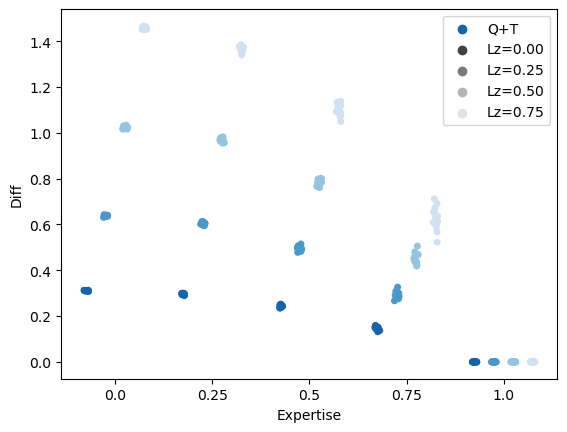

{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 5.551115123125783e-17, 51: 1.1102230246251565e-16, 52: 1.6653345369377348e-16, 53: 2.220446049250313e-16, 54: 2.220446049250313e-16, 55: 3.3306690738754696e-16, 56: 2.220446049250313e-16, 57: 4.440892098500626e-16, 58: 2.220446049250313e-16, 59: 2.220446049250313e-16, 60: 4.440892098500626e-16, 61: 6.661338147750939e-16, 62: 4.440892098500626e-16, 63: 4.440892098500626e-16, 64: 6.661338147750939e-16, 65: 6.661338147750939e-16, 66: 4.440892098500626e-16, 67: 6.661338147750939e-16, 68: 2.220446049250313e-16, 69: 4.440892098500626e-16, 70: 4.4408920985

In [194]:
# create palette
mechanisms = ['Q+T']
laziness_vec = [0.0, 0.25, 0.5, 0.75]
color_range = np.linspace(0.8, 0.2, len(laziness_vec))
colors=['Blues', 'Greens', 'Reds', 'Purples']
palette = {}
for jj, m in enumerate(mechanisms):
    color = mpl.colormaps[colors[jj]]
    for ii, l in enumerate(laziness_vec):
        key='%s//%0.02f' % (m, l,)
        palette[key] = color(color_range[ii])

ax = sns.stripplot(
    data=dff, x="avg_expertise", y="Diff", hue="Hue",
    dodge=True, zorder=1, legend=False, palette=palette,
)
plt.xlabel('Expertise')
plt.ylabel('Diff')
# plt.legend(title='Mechanism//Laziness')
# create custom legend
for ii, m in enumerate(mechanisms):
    ax.scatter([], [], color=mpl.colormaps[colors[ii]](0.8), label=mechanisms[ii])
for ii, l in enumerate(laziness_vec):
    ax.scatter([], [], color=mpl.colormaps['Greys'](color_range[ii]), label='Lz=%0.02f' % l)
ax.legend(loc='upper right')

TypeError: float() argument must be a string or a real number, not 'dict'

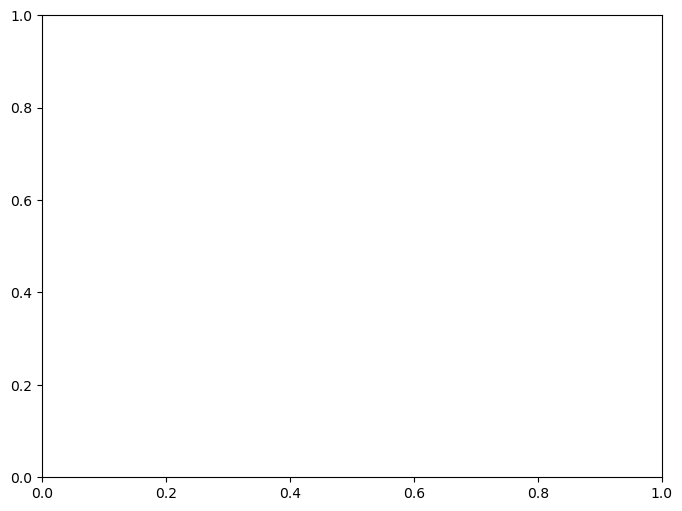

In [87]:
sorted_qt_project2funding = dict(sorted(qt_project2funding.items(), key=lambda item: item[1], reverse=True))

# Plot the numbers
plt.figure(figsize=(8, 6))  # Optional: Set the figure size
plt.plot(qt_diff, marker='o', linestyle='-', color='b')

# Add labels and title
plt.title("Amount of Vote Casted on Projects by Simulation", fontsize=14)
plt.xlabel("Projects", fontsize=12)
plt.ylabel("Vote Amount", fontsize=12)

# Show grid and legend
plt.grid(True)

# Display the plot
plt.show()
